In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import wandb
from tensorflow.keras.callbacks import ModelCheckpoint
from wandb.integration.keras import WandbCallback
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

I0000 00:00:1777213639.009470 1613755 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#Change 

In [3]:
#Entrainer juste sur clean et mixed -> mixed est un melange de cross-out

In [4]:
# Binary classification

In [5]:
def preprocess(image, label):
    # Normalisation [0,255] → [0,1]
    image = tf.cast(image, tf.float32) / 255.0
    
    # Grayscale 
    image = tf.image.rgb_to_grayscale(image)
    
    # Repasser en 3 canaux (important pour CNN pré-entraînés)
    image = tf.image.grayscale_to_rgb(image)
    
    return image, label

In [6]:
def invert(image):
    return 1.0 - image

In [35]:
wandb.init(project="cross-out-detection")

callbacks = [
    WandbMetricsLogger(),  
    WandbModelCheckpoint(
        "best_model.keras",   
        monitor="val_loss",
        save_best_only=True,
        mode="min")]

In [4]:
checkpoint = ModelCheckpoint(
    "simple_CNN.h5",          # fichier de sauvegarde
    monitor="val_loss",       # métrique à surveiller
    save_best_only=True,      # 🔥 garde uniquement le meilleur
    mode="min",               # min pour loss, max pour accuracy
    verbose=1)


In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.02),   
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.2),
])

I0000 00:00:1777213678.291993 1613755 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9434 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:21:00.0, compute capability: 7.5


In [38]:
# Charge the dataset
# Parameters
img_size = (70, 155)
batch_size = 32

#load dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/train/images",
    labels="inferred",
    label_mode="binary",
    class_names=["CLEAN", "MIXED"],  
    image_size=img_size,
    batch_size=32
)

# Load validation data
val_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/val/images",
    labels="inferred",
    label_mode="binary",
    class_names=["CLEAN", "MIXED"],  
    image_size=img_size,
    batch_size=32
)
#Load test data
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/test/images",
    labels="inferred",
    label_mode="binary",
    class_names=["CLEAN", "MIXED"],  
    image_size=img_size,
    batch_size=32
)

# Preprocess
train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)

# Optionnel : ajouter inversion aléatoire
def random_invert(image, label):
    return tf.cond(
        tf.random.uniform(()) > 0.5,
        lambda: (invert(image), label),
        lambda: (image, label)
    )

train_dataset = train_dataset.map(random_invert)

Found 95994 files belonging to 2 classes.
Found 15118 files belonging to 2 classes.
Found 40612 files belonging to 2 classes.


In [39]:
#CNN

model = models.Sequential([
    data_augmentation,
    # Small details captured
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(70, 155,3)),
    
    # Pooling 
    layers.MaxPooling2D((2,2)),
    
    # More complex details captured
    layers.Conv2D(64, (3,3), activation='relu'),
    
    # Pooling
    layers.MaxPooling2D((2,2)),
    
    # Flatten for dense layer
    layers.Flatten(),
    
    layers.Dense(64, activation='relu'),
    
    # Output (2 classes)
    layers.Dense(1, activation='sigmoid')])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
# Compilation
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [41]:
# Training

model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[callbacks, checkpoint])

Epoch 1/50
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8436 - loss: 0.3686
Epoch 1: val_loss improved from None to 0.33621, saving model to simple_CNN.h5



Epoch 1: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 100s 33ms/step - accuracy: 0.8960 - loss: 0.2383 - val_accuracy: 0.8473 - val_loss: 0.3362
Epoch 2/50
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9281 - loss: 0.1568
Epoch 2: val_loss improved from 0.33621 to 0.30109, saving model to simple_CNN.h5



Epoch 2: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 96s 32ms/step - accuracy: 0.9288 - loss: 0.1542 - val_accuracy: 0.8623 - val_loss: 0.3011
Epoch 3/50
2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9334 - loss: 0.1351
Epoch 3: val_loss improved from 0.30109 to 0.24336, saving model to simple_CNN.h5



Epoch 3: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 114s 38ms/step - accuracy: 0.9347 - loss: 0.1314 - val_accuracy: 0.8888 - val_loss: 0.2434
Epoch 4/50
2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9357 - loss: 0.1283
Epoch 4: val_loss improved from 0.24336 to 0.22852, saving model to simple_CNN.h5



Epoch 4: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 97s 32ms/step - accuracy: 0.9362 - loss: 0.1246 - val_accuracy: 0.8917 - val_loss: 0.2285
Epoch 5/50
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9365 - loss: 0.1197
Epoch 5: val_loss improved from 0.22852 to 0.19976, saving model to simple_CNN.h5


...


Epoch 26: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 96s 32ms/step - accuracy: 0.9447 - loss: 0.0950 - val_accuracy: 0.9197 - val_loss: 0.1557
Epoch 27/50
2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9461 - loss: 0.0946
Epoch 27: val_loss did not improve from 0.15568
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 91s 30ms/step - accuracy: 0.9455 - loss: 0.0956 - val_accuracy: 0.9066 - val_loss: 0.1866
Epoch 28/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9443 - loss: 0.0957
Epoch 28: val_loss did not improve from 0.15568
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 91s 30ms/step - accuracy: 0.9444 - loss: 0.0968 - val_accuracy: 0.9161 - val_loss: 0.1674
Epoch 29/50
2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9456 - loss: 0.0959
Epoch 29: val_loss did not improve from 0.15568
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 91s 30ms/step - accuracy: 0.9459 - loss: 0.0956 - val_accuracy: 0.9196 - val_loss: 0.1590
Epoch 30/50
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/s


Epoch 34: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 97s 32ms/step - accuracy: 0.9456 - loss: 0.0942 - val_accuracy: 0.9241 - val_loss: 0.1459
Epoch 35/50
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9454 - loss: 0.0982
Epoch 35: val_loss did not improve from 0.14594
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 91s 30ms/step - accuracy: 0.9455 - loss: 0.0974 - val_accuracy: 0.9006 - val_loss: 0.2095
Epoch 36/50
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9463 - loss: 0.0936
Epoch 36: val_loss did not improve from 0.14594
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 92s 30ms/step - accuracy: 0.9467 - loss: 0.0919 - val_accuracy: 0.9142 - val_loss: 0.1794
Epoch 37/50
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9465 - loss: 0.0927
Epoch 37: val_loss did not improve from 0.14594
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 90s 30ms/step - accuracy: 0.9464 - loss: 0.0918 - val_accuracy: 0.9193 - val_loss: 0.1619
Epoch 38/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/s


Epoch 40: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 97s 32ms/step - accuracy: 0.9466 - loss: 0.0915 - val_accuracy: 0.9252 - val_loss: 0.1440
Epoch 41/50
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9463 - loss: 0.0895
Epoch 41: val_loss did not improve from 0.14396
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 92s 30ms/step - accuracy: 0.9471 - loss: 0.0890 - val_accuracy: 0.9235 - val_loss: 0.1484
Epoch 42/50
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9468 - loss: 0.0908
Epoch 42: val_loss did not improve from 0.14396
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 90s 30ms/step - accuracy: 0.9467 - loss: 0.0908 - val_accuracy: 0.9255 - val_loss: 0.1457
Epoch 43/50
2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9470 - loss: 0.0899
Epoch 43: val_loss improved from 0.14396 to 0.14003, saving model to simple_CNN.h5



Epoch 43: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 98s 33ms/step - accuracy: 0.9466 - loss: 0.0901 - val_accuracy: 0.9235 - val_loss: 0.1400
Epoch 44/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9472 - loss: 0.0886
Epoch 44: val_loss did not improve from 0.14003
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 93s 31ms/step - accuracy: 0.9472 - loss: 0.0900 - val_accuracy: 0.9159 - val_loss: 0.1645
Epoch 45/50
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9479 - loss: 0.0892
Epoch 45: val_loss improved from 0.14003 to 0.13810, saving model to simple_CNN.h5



Epoch 45: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 96s 32ms/step - accuracy: 0.9471 - loss: 0.0896 - val_accuracy: 0.9257 - val_loss: 0.1381
Epoch 46/50
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9475 - loss: 0.0881
Epoch 46: val_loss did not improve from 0.13810
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 91s 30ms/step - accuracy: 0.9468 - loss: 0.0899 - val_accuracy: 0.9159 - val_loss: 0.1692
Epoch 47/50
2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9472 - loss: 0.0882
Epoch 47: val_loss did not improve from 0.13810
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 91s 30ms/step - accuracy: 0.9469 - loss: 0.0888 - val_accuracy: 0.9098 - val_loss: 0.1990
Epoch 48/50
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9471 - loss: 0.0901
Epoch 48: val_loss did not improve from 0.13810
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 93s 31ms/step - accuracy: 0.9477 - loss: 0.0894 - val_accuracy: 0.9212 - val_loss: 0.1505
Epoch 49/50
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/s

In [42]:
model = load_model("simple_CNN.h5")

In [43]:
# Evaluation
test_loss, test_acc = model.evaluate(test_dataset)
print("Accuracy :", test_acc)

1270/1270 ━━━━━━━━━━━━━━━━━━━━ 91s 70ms/step - accuracy: 0.9388 - loss: 0.1079
Accuracy : 0.938811182975769


In [44]:
y_pred_probs = model.predict(test_dataset)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

y_true = np.concatenate([y for x, y in test_dataset], axis=0).astype(int)

cm = confusion_matrix(y_true, y_pred)
print(cm)

1270/1270 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step
[[11102  9204]
 [11171  9135]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step


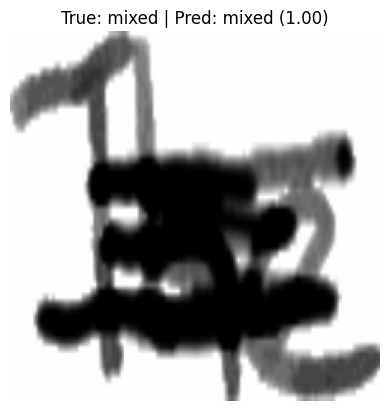

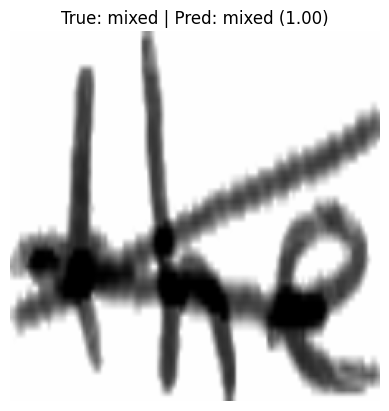

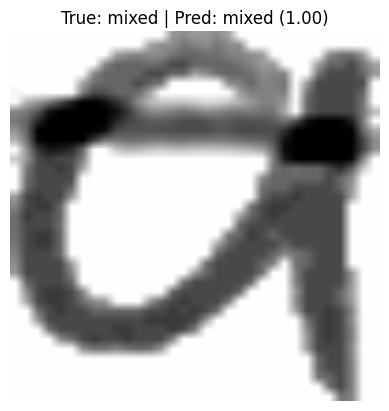

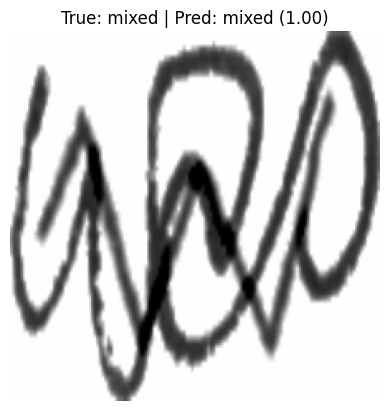

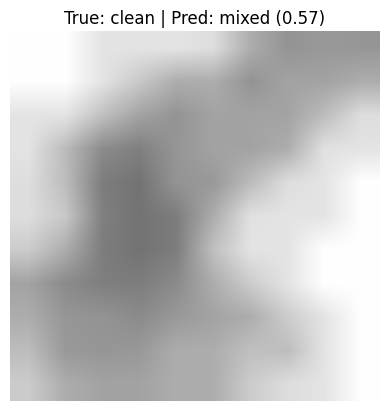

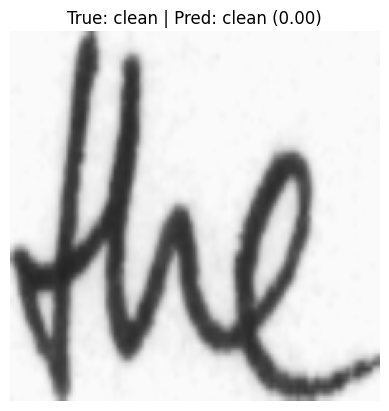

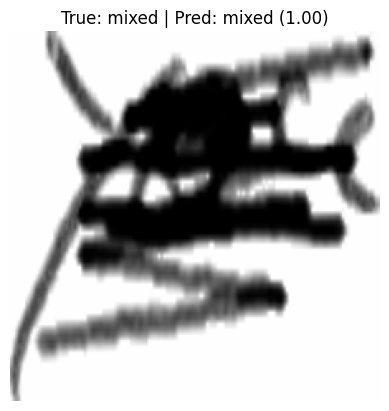

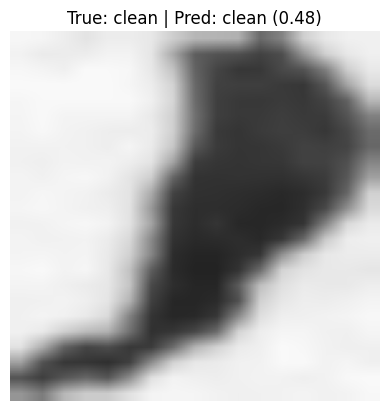

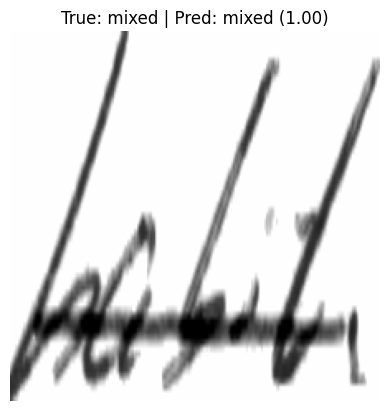

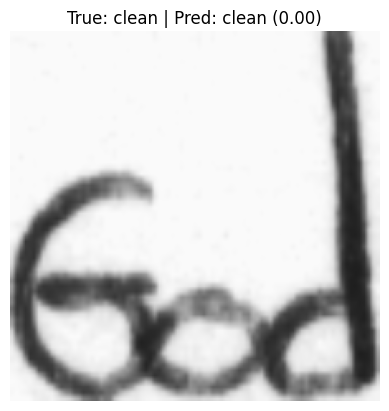

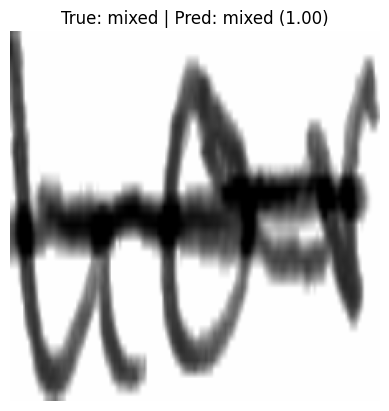

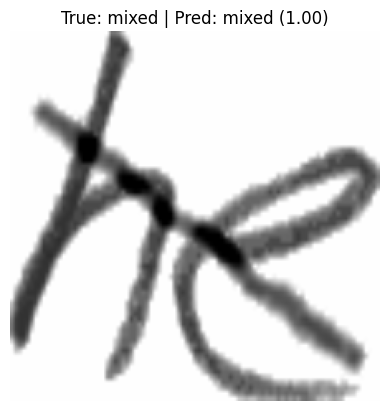

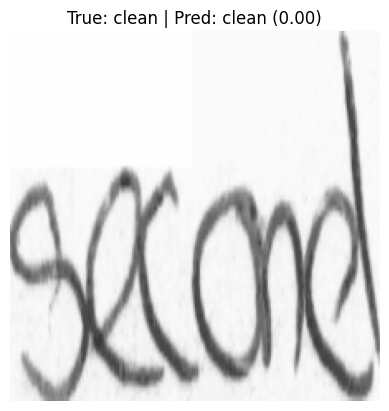

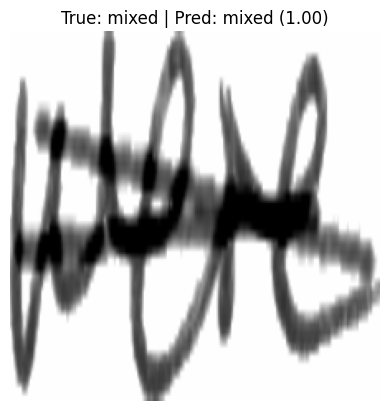

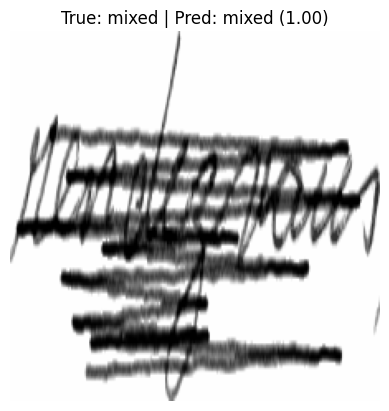

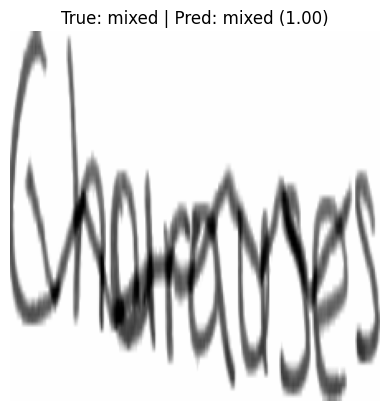

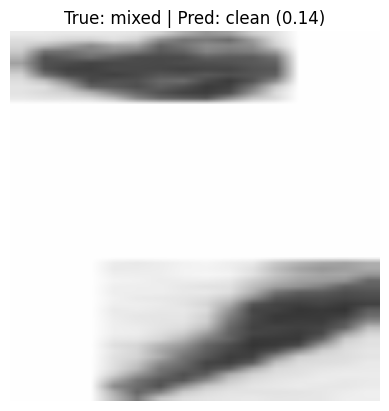

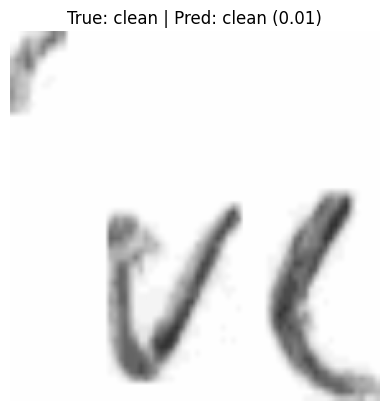

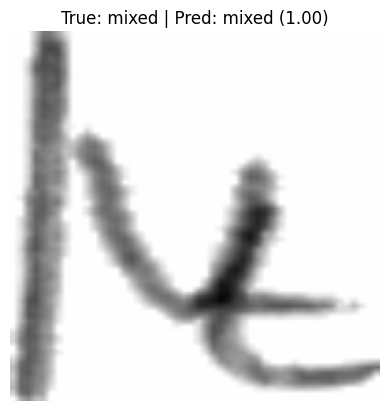

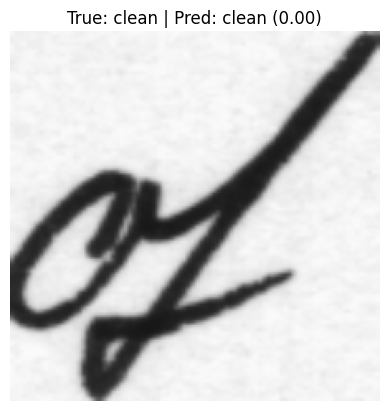

In [45]:
class_names = ["clean", "mixed"]  # adapte si besoin

for images, labels in test_dataset.take(1):
    preds = model.predict(images)

    for i in range(20):
        plt.imshow(images[i].numpy())
        
        true_label = int(labels[i].numpy()[0])
        pred_label = int(preds[i][0] > 0.5)

        plt.title(f"True: {class_names[true_label]} | Pred: {class_names[pred_label]} ({preds[i][0]:.2f})")
        plt.axis("off")
        plt.show()

In [17]:
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
print(np.unique(y_true, return_counts=True))

(array([0., 1.], dtype=float32), array([47997, 47997]))


In [18]:
print("y_pred:", np.unique(y_pred, return_counts=True))

y_pred: (array([0, 1]), array([52305, 43689]))


In [6]:
wandb.finish()

In [20]:
# Multi-class classification

In [8]:
wandb.init(project="cross-out-detection")

callbacks = [
    WandbMetricsLogger(),  
    WandbModelCheckpoint(
        "best_model.keras",   
        monitor="val_loss",
        save_best_only=True,
        mode="min")]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: linneahejsupergroup (linneahejsupergroup-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING When using `save_best_only`, ensure that the `filepath` argument contains formatting placeholders like `{epoch:02d}` or `{batch:02d}`. This ensures correct interpretation of the logged artifacts.


In [9]:
checkpoint = ModelCheckpoint(
    "multiclass_CNN.h5",          # fichier de sauvegarde
    monitor="val_loss",       # métrique à surveiller
    save_best_only=True,      # 🔥 garde uniquement le meilleur
    mode="min",               # min pour loss, max pour accuracy
    verbose=1)


In [10]:
# Charge the dataset
# Parameters
img_size = (70, 155)
batch_size = 32

#load dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/train/images",
    labels="inferred",
    label_mode="int",
    class_names=["CROSS", "DIAGONAL", "DOUBLE_LINE","SCRATCH", "SINGLE_LINE", "WAVE", "ZIG_ZAG", "CLEAN"],  
    image_size=img_size,
    batch_size=32
)

# Load validation data
val_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/val/images",
    labels="inferred",
    label_mode="int",
    class_names=["CROSS", "DIAGONAL", "DOUBLE_LINE","SCRATCH", "SINGLE_LINE", "WAVE", "ZIG_ZAG", "CLEAN"],  
    image_size=img_size,
    batch_size=32
)
#Load test data
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/test/images",
    labels="inferred",
    label_mode="int",
    class_names=["CROSS", "DIAGONAL", "DOUBLE_LINE","SCRATCH", "SINGLE_LINE", "WAVE", "ZIG_ZAG", "CLEAN"],  
    image_size=img_size,
    batch_size=32
)

# Preprocess
train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)

# Optionnel : ajouter inversion aléatoire
def random_invert(image, label):
    return tf.cond(
        tf.random.uniform(()) > 0.5,
        lambda: (invert(image), label),
        lambda: (image, label)
    )

train_dataset = train_dataset.map(random_invert)

Found 383976 files belonging to 8 classes.
Found 60472 files belonging to 8 classes.
Found 162448 files belonging to 8 classes.


In [11]:
#CNN

model = models.Sequential([
    data_augmentation,
    # Small details captured
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(70, 155,3)),
    
    # Pooling 
    layers.MaxPooling2D((2,2)),
    
    # More complex details captured
    layers.Conv2D(64, (3,3), activation='relu'),
    
    # Pooling
    layers.MaxPooling2D((2,2)),
    
    # More complex details captured
    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Conv2D(256, (3,3), activation='relu'),

    
    # Pooling
    layers.MaxPooling2D((2,2)),
    
    # Flatten for dense layer
    layers.Flatten(),
    
    layers.Dense(64, activation='relu'),
    
    # Output (8 classes)
    layers.Dense(8, activation='softmax')])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [ ]:
# Training
model.fit(train_dataset, epochs=50, validation_data=val_dataset, callbacks = [callbacks, checkpoint])

Epoch 1/50


I0000 00:00:1777213742.997959 1614108 cuda_dnn.cc:461] Loaded cuDNN version 91900


12000/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6620 - loss: 0.8575
Epoch 1: val_loss improved from None to 0.54154, saving model to multiclass_CNN.h5



Epoch 1: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 521s 43ms/step - accuracy: 0.7478 - loss: 0.6289 - val_accuracy: 0.7792 - val_loss: 0.5415
Epoch 2/50
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8129 - loss: 0.4604
Epoch 2: val_loss improved from 0.54154 to 0.43134, saving model to multiclass_CNN.h5



Epoch 2: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 506s 42ms/step - accuracy: 0.8193 - loss: 0.4460 - val_accuracy: 0.8266 - val_loss: 0.4313
Epoch 3/50
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8328 - loss: 0.4136
Epoch 3: val_loss did not improve from 0.43134
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 499s 42ms/step - accuracy: 0.8353 - loss: 0.4075 - val_accuracy: 0.8278 - val_loss: 0.4386
Epoch 4/50
  122/12000 ━━━━━━━━━━━━━━━━━━━━ 7:33 38ms/step - accuracy: 0.8414 - loss: 0.4291

...


Epoch 18: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 497s 41ms/step - accuracy: 0.8702 - loss: 0.3252 - val_accuracy: 0.8530 - val_loss: 0.3666
Epoch 19/50
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8708 - loss: 0.3238
Epoch 19: val_loss did not improve from 0.36659
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 497s 41ms/step - accuracy: 0.8712 - loss: 0.3233 - val_accuracy: 0.8477 - val_loss: 0.3800
Epoch 20/50
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8716 - loss: 0.3228
Epoch 20: val_loss did not improve from 0.36659
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 498s 41ms/step - accuracy: 0.8720 - loss: 0.3217 - val_accuracy: 0.8513 - val_loss: 0.3842
Epoch 21/50
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8716 - loss: 0.3214
Epoch 21: val_loss did not improve from 0.36659
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 497s 41ms/step - accuracy: 0.8719 - loss: 0.3214 - val_accuracy: 0.8507 - val_loss: 0.3788
Epoch 22/50
11999/12000 ━━━━━━


Epoch 26: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 500s 42ms/step - accuracy: 0.8732 - loss: 0.3175 - val_accuracy: 0.8544 - val_loss: 0.3631
Epoch 27/50
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8732 - loss: 0.3188
Epoch 27: val_loss did not improve from 0.36314
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 494s 41ms/step - accuracy: 0.8731 - loss: 0.3197 - val_accuracy: 0.8498 - val_loss: 0.3832
Epoch 28/50
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8744 - loss: 0.3169
Epoch 28: val_loss did not improve from 0.36314
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 494s 41ms/step - accuracy: 0.8743 - loss: 0.3173 - val_accuracy: 0.8527 - val_loss: 0.3708
Epoch 29/50
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8711 - loss: 0.3262
Epoch 29: val_loss did not improve from 0.36314
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 495s 41ms/step - accuracy: 0.8728 - loss: 0.3211 - val_accuracy: 0.8519 - val_loss: 0.3754
Epoch 30/50
12000/12000 ━━━━━━


Epoch 32: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 501s 42ms/step - accuracy: 0.8744 - loss: 0.3165 - val_accuracy: 0.8580 - val_loss: 0.3611
Epoch 33/50
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8743 - loss: 0.3166
Epoch 33: val_loss improved from 0.36108 to 0.35882, saving model to multiclass_CNN.h5



Epoch 33: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 498s 41ms/step - accuracy: 0.8744 - loss: 0.3173 - val_accuracy: 0.8566 - val_loss: 0.3588
Epoch 34/50
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8741 - loss: 0.3156
Epoch 34: val_loss did not improve from 0.35882
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 495s 41ms/step - accuracy: 0.8745 - loss: 0.3157 - val_accuracy: 0.8540 - val_loss: 0.3720
Epoch 35/50
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8757 - loss: 0.3161
Epoch 35: val_loss did not improve from 0.35882
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 496s 41ms/step - accuracy: 0.8755 - loss: 0.3159 - val_accuracy: 0.8566 - val_loss: 0.3647
Epoch 36/50
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8742 - loss: 0.3165
Epoch 36: val_loss did not improve from 0.35882
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 498s 41ms/step - accuracy: 0.8748 - loss: 0.3157 - val_accuracy: 0.8447 - val_loss: 0.3973
Epoch 37/50
11999/12000 ━━━━━━

KeyboardInterrupt: 

In [ ]:
model = load_model("multiclass_CNN.h5")

In [ ]:
# Evaluation
test_loss, test_acc = model.evaluate(test_dataset)
print("Accuracy :", test_acc)

In [ ]:
# récupère automatiquement les noms des classes
class_names = ["CROSS", "DIAGONAL", "DOUBLE_LINE","SCRATCH", "SINGLE_LINE", "WAVE", "ZIG_ZAG", "CLEAN"]

for images, labels in test_dataset.take(1):
    preds = model.predict(images)

    for i in range(6):
        plt.imshow(images[i].numpy())  

        # labels vrais
        true_label = int(labels[i].numpy())

        # prédiction
        pred_label = np.argmax(preds[i])

        plt.title(
            f"True: {class_names[true_label]} | "
            f"Pred: {class_names[pred_label]} ({np.max(preds[i]):.2f})"
        )
        plt.axis("off")
        plt.show()